# setup

In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
def scatter(a, b, log=False, log10=False, diag=True, ma=0, ax=None, c='black', s=1,
            label=None, alpha=1, aspect=False, cmap=None, return_scat_obj=False, args={}):
    # Scatters a vs b of ax (default plt). Can apply:
    #   -   log(x+1) transformation (optional)
    #   -   label (optional)
    #   -   color (default black)
    #   -   size of point (default 1)
    #   -   alpha factor (default 1)
    #   -   aspect ratio equal (optional)
    #   -   diagonal line from 0 to ma (if provided) or to max(a,b) (optional)

    ax_ = ax if ax is not None else plt
    if log:
        a = a+1
        b = b+1
        ax_.semilogx(base=2)
        ax_.semilogy(base=2)
    elif log10:
        a = a+1
        b = b+1
        ax_.semilogx(base=10)
        ax_.semilogy(base=10)
    if diag:
        if ma == 0: ma = np.max([a.max(), b.max()])
        ax_.plot([0, ma], [0, ma], linewidth=1, c='black')
    if type(c) is str or type(c) == np.ndarray:
        scat = ax_.scatter(a, b, s=s, c=c, alpha=alpha, label=label, cmap=cmap, **args)
    else:
        scat = ax_.scatter(a, b, s=s, color=c, alpha=alpha, label=label, cmap=cmap, **args)
    if aspect:
        if ax is None: ax_.gca().set_aspect('equal')
        else: ax_.set_aspect('equal')
    if return_scat_obj: return ax_, scat
    else: return ax_



def add_labels(title=None, xlabel=None, ylabel=None, xlim=None, ylim=None,
               xticks=None, xticklabels=None, xtickrotation=None,
               yticks=None, yticklabels=None, ytickrotation=None,
               aspect=False, legend=False, ax=None):
    # Applies labels (if provided)

    if ax is None or ax is plt:
        if title is not None: plt.title(title)
        if xlabel is not None: plt.xlabel(xlabel)
        if ylabel is not None: plt.ylabel(ylabel)
        if xlim is not None: plt.xlim(xlim)
        if ylim is not None: plt.ylim(ylim)
        if xticks is not None:
            if xtickrotation is not None: plt.xticks(xticks, xticklabels, rotation=xtickrotation)
            else: plt.xticks(xticks, xticklabels)
        if yticks is not None:
            if ytickrotation is not None: plt.yticks(yticks, yticklabels, rotation=ytickrotation)
            else: plt.yticks(yticks, yticklabels)
        if aspect: plt.gca().set_aspect('equal')
        if legend: plt.legend()
        return plt
    else:
        if title is not None: ax.set_title(title)
        if xlabel is not None: ax.set_xlabel(xlabel)
        if ylabel is not None: ax.set_ylabel(ylabel)
        if xlim is not None: ax.set_xlim(xlim)
        if ylim is not None: ax.set_ylim(ylim)
        if xticks is not None: ax.set_xticks(xticks)
        if yticks is not None: ax.set_yticks(yticks)
        if xticklabels is not None:
            if xtickrotation is not None: ax.set_xticklabels(xticklabels, rotation=xtickrotation)
            else: ax.set_xticklabels(xticklabels)
        if yticklabels is not None:
            if ytickrotation is not None: ax.set_yticklabels(yticklabels, rotation=ytickrotation)
            else: ax.set_yticklabels(yticklabels)
        if aspect: ax.set_aspect('equal')
        if legend: ax.legend()
        return ax


def show(title=None, xlabel=None, ylabel=None, xlim=None, ylim=None, aspect=False,
         fig=plt, figname=None, tight_layout=True, dpi=300,
         savefig=True, showfig=True, legend=False, savepdf=False):
    # Finishes plot:
    #   -   Applies labels (if provided)
    #   -   Applies legend and tight_layout (optional)
    #   -   Saves to figname (optional)
    #   -   Shows fig (optional - otherwise delete it)

    if type(fig) is plt.Figure and title is not None: fig.suptitle(title)
    if type(fig) is not plt.Figure:
        add_labels(title=title, xlabel=xlabel, ylabel=ylabel, xlim=xlim, ylim=ylim, aspect=aspect, ax=None)
    else:
        add_labels(xlabel=xlabel, ylabel=ylabel, aspect=aspect, ax=None)

    if legend: plt.legend()
    if tight_layout: fig.tight_layout()
    if savefig and figname is not None: fig.savefig(figname.parent/f'{figname.name}.png', dpi=dpi)
    if savepdf and figname is not None: fig.savefig(figname.parent/f'{figname.name}.pdf')
    if showfig: plt.show()
    else: fig.clf()


# generate means

In [19]:
n_genes = 1000
mean_healthy = np.zeros(n_genes)
mean_healthy[:n_genes // 2] = 100
mean_disease = np.zeros(n_genes)
mean_disease[n_genes // 2:] = 100
mean_healthy.shape, mean_disease.shape

((1000,), (1000,))

# generate data

In [73]:
n_healthy_samples = 200
n_disease_samples = 300
healthy_part = np.random.normal(mean_healthy[:, None], 0.1, size=(n_genes, n_healthy_samples + n_disease_samples)).clip(min=0)
disease_part = np.random.normal(mean_disease[:, None], 0.1, size=(n_genes, n_disease_samples)).clip(min=0)
healthy_part.shape, disease_part.shape

((1000, 500), (1000, 300))

In [82]:
healthy_data = healthy_part[:, :n_healthy_samples]
disease_data_theta05 = 0.5 * healthy_part[:, n_healthy_samples:] + 0.5 * disease_part
healthy_data.shape, disease_data_theta05.shape

((1000, 200), (1000, 300))

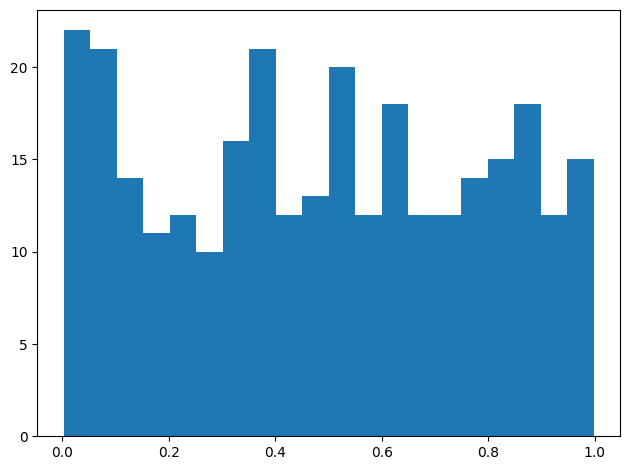

(1000, 300)

In [84]:
theta = np.random.uniform(0, 1, n_disease_samples)
plt.hist(theta, bins=20)
show()

disease_data_uniform_theta = (1 - theta) * healthy_part[:, n_healthy_samples:] + theta * disease_part
disease_data_uniform_theta.shape

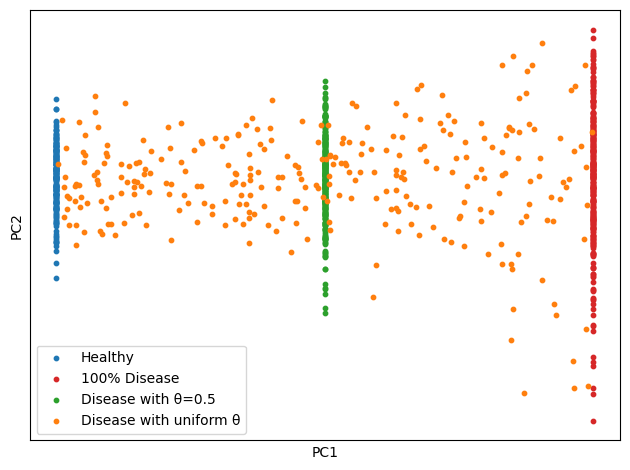

In [88]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
embedding = pca.fit_transform(np.concatenate([healthy_data.T, disease_part.T, disease_data_theta05.T, disease_data_uniform_theta.T], axis=0))
healthy_data_embedding = embedding[:n_healthy_samples]
disease_part_embedding = embedding[n_healthy_samples:n_healthy_samples + n_disease_samples]
disease_data_theta05_embedding = embedding[n_healthy_samples + n_disease_samples:n_healthy_samples + 2 * n_disease_samples]
disease_data_uniform_theta_embedding = embedding[n_healthy_samples + 2 * n_disease_samples:]

# plot
scatter(healthy_data_embedding[:, 0], healthy_data_embedding[:, 1], s=10, diag=0, label='Healthy', c='tab:blue')
scatter(disease_part_embedding[:, 0], disease_part_embedding[:, 1], s=10, diag=0, c='tab:red', label='100% Disease')
scatter(disease_data_theta05_embedding[:, 0], disease_data_theta05_embedding[:, 1], s=10, diag=0, c='tab:green', label='Disease with θ=0.5')
scatter(disease_data_uniform_theta_embedding[:, 0], disease_data_uniform_theta_embedding[:, 1], s=10, diag=0, c='tab:orange', label='Disease with uniform θ')
add_labels(xticks=[], yticks=[])
show(xlabel='PC1', ylabel='PC2', legend=1)


# save data

In [99]:
import pandas as pd
healthy_data_df = pd.DataFrame(
    healthy_data, index=[f'Gene{i}' for i in range(n_genes)],
    columns=[f'Healthy_Sample{i}' for i in range(n_healthy_samples)]
)
healthy_data_df.to_csv('healthy_data.csv')

In [100]:
disease_data_theta05_df = pd.DataFrame(
    disease_data_theta05, index=[f'Gene{i}' for i in range(n_genes)],
    columns=[f'Disease_Sample{i}' for i in range(n_disease_samples)]
)
disease_data_theta05_df.to_csv('disease_data_theta05.csv')

In [101]:
disease_data_uniform_theta_df = pd.DataFrame(
    disease_data_uniform_theta, index=[f'Gene{i}' for i in range(n_genes)],
    columns=[f'Disease_Sample{i}' for i in range(n_disease_samples)]
)
disease_data_uniform_theta_df.to_csv('disease_data_uniform_theta.csv')